<a href="https://colab.research.google.com/github/James-Patrick416/Quantam/blob/main/Q.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

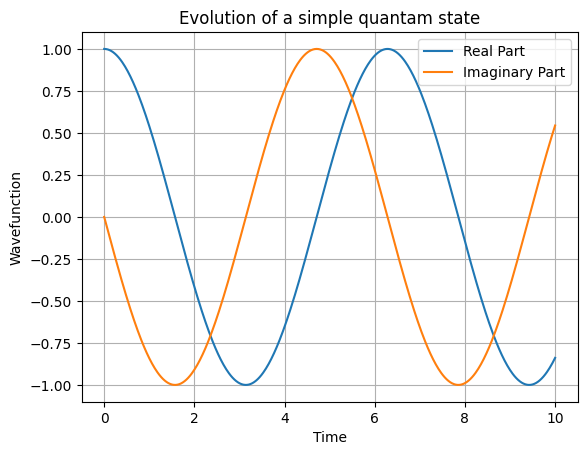

In [ ]:
# starting out with the time dependent schrodinger equation since its foundation
import numpy as np
import matplotlib.pyplot as plt

# constants
hbar = 1
E = 1

# Time
t = np.linspace(0, 10, 500)

# simple quantam state
psi = np.exp(-1j * E * t / hbar)

plt.plot(t, psi.real, label="Real Part")
plt.plot(t, psi.imag, label="Imaginary Part")
plt.xlabel("Time")
plt.ylabel("Wavefunction")
plt.title("Evolution of a simple quantam state")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!pip install qiskit qiskit-aer matplotlib

In [ ]:
!pip install pylatexenc -q

Circuit Diagram:


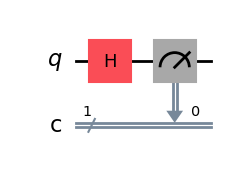


Measurement Counts: {'0': 503, '1': 497}


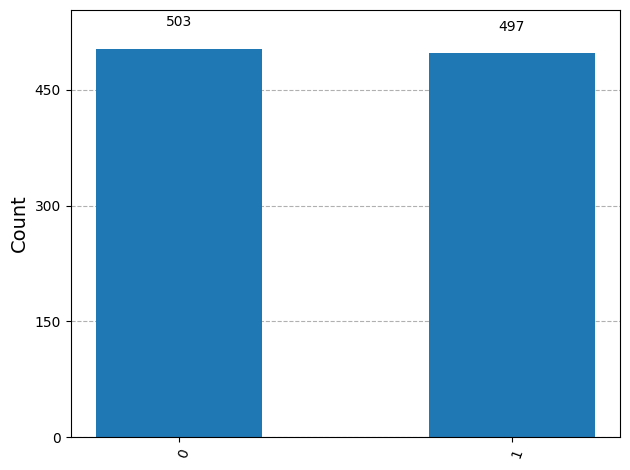

In [ ]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# create a quantum circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# apply a Hadamard gate to the qubit
qc.h(0)

# measure the qubit 0 into classical bit 0
qc.measure(0, 0)

# display the circuit structure
print("Circuit Diagram:")
display(qc.draw('mpl'))

# set up the local Qiskit Aer simulator
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

# run the circuit 1000 times (shots)
job = simulator.run(compiled_circuit, shots=1000)
result = job.result()

# retrieve and plot measurement outcomes
counts = result.get_counts(compiled_circuit)
print("\nMeasurement Counts:", counts)
display(plot_histogram(counts))

✓ Libraries installed successfully!
✓ Libraries imported successfully!
Step 1: Created circuit with 2 qubits and 2 classical bits
Circuit has 2 qubits and 2 classical bits
Step 2: Creating Bell state |Φ⁺⟩ = (|00⟩ + |11⟩) / √2
  → Applied Hadamard gate to qubit 0 (creates superposition)
  → Applied CNOT gate (control: qubit 0, target: qubit 1)
  → Now qubits are ENTANGLED!
Step 3: Visualizing the quantum circuit

Quantum Circuit Diagram:
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               

Circuit explanation:
  ┌───┐     
q0: ┤ H ├──■──
  └───┘  │  
q1: ──────X──
         │  
c0: ═════╪══
         │  
c1: ═════╪══
         └──
Step 4: Adding measurements to the circuit
  → Added measurement gates to both qubits
  → The qubits will collapse to either |00⟩ or |11⟩

Final Circuit Diagram (with measurements):
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/════════

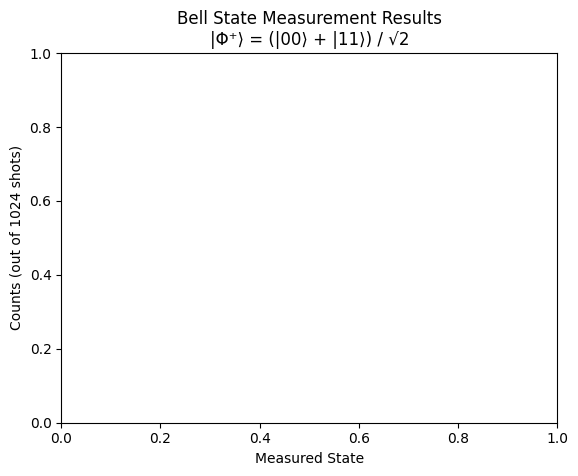


Histogram interpretation:
- The bars show how many times each state was measured
- For perfect entanglement, you should see two equal bars at |00⟩ and |11⟩
- Small differences are due to statistical noise

BONUS: Understanding the Quantum State
The Bell state as a mathematical vector:
|Φ⁺⟩ = [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

This means the state is:
|Φ⁺⟩ = (|00⟩ + |11⟩) / √2

The coefficients show the probability amplitudes:
  |00⟩: amplitude = 0.707+0.000j, probability = 50.0%
  |01⟩: amplitude = 0.000+0.000j, probability = 0.0%
  |10⟩: amplitude = 0.000+0.000j, probability = 0.0%
  |11⟩: amplitude = 0.707+0.000j, probability = 50.0%

DEMONSTRATING ENTANGLEMENT
When we measure only qubit 0:
  Qubit 0 measured as 1: 50.4%
  Qubit 0 measured as 0: 49.6%

Because the qubits are entangled:
- If qubit 0 is |0⟩, qubit 1 MUST be |0⟩
- If qubit 0 is |1⟩, qubit 1 MUST be |1⟩
- This correlation exists even though the qubits are separate!
  (Einstein called this 'sp

In [2]:
# ============================================================
# QUANTUM BELL STATE CREATION AND MEASUREMENT
# UPDATED FOR QISKIT 2.5.1+
# ============================================================
# This code demonstrates the creation of an entangled Bell state
# |Φ⁺⟩ = (|00⟩ + |11⟩) / √2 using quantum gates
# ============================================================

# Step 1: Install required libraries (if not already installed)
!pip install qiskit
!pip install qiskit-aer
!pip install matplotlib

print("✓ Libraries installed successfully!")
print("="*50)

# Step 2: Import necessary libraries (UPDATED FOR QISKIT 2.5.1)
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator  # CHANGED: Aer moved to qiskit_aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector  # For state vector simulation
import matplotlib.pyplot as plt
import numpy as np

print("✓ Libraries imported successfully!")
print("="*50)

# ============================================================
# BUILDING THE QUANTUM CIRCUIT
# ============================================================

# Step 3: Create a quantum circuit with 2 qubits and 2 classical bits
# - QuantumRegister(2): Creates 2 quantum bits (qubits)
# - ClassicalRegister(2): Creates 2 classical bits for measurement results
# - QuantumCircuit: Combines them into a circuit
qreg = QuantumRegister(2, 'q')    # Two qubits
creg = ClassicalRegister(2, 'c')  # Two classical bits for output
circuit = QuantumCircuit(qreg, creg)

# Display the initial circuit structure
print("Step 1: Created circuit with 2 qubits and 2 classical bits")
print(f"Circuit has {circuit.num_qubits} qubits and {circuit.num_clbits} classical bits")
print("="*50)

# ============================================================
# STEP 4: CREATE THE BELL STATE
# ============================================================
# The Bell state |Φ⁺⟩ = (|00⟩ + |11⟩) / √2 is created by:
# 1. Applying Hadamard gate (H) to first qubit to create superposition
# 2. Applying CNOT gate with control = first qubit, target = second qubit
# This creates entanglement between the qubits

print("Step 2: Creating Bell state |Φ⁺⟩ = (|00⟩ + |11⟩) / √2")

# Apply Hadamard gate to qubit 0
# H gate creates superposition: |0⟩ → (|0⟩ + |1⟩) / √2
circuit.h(qreg[0])
print("  → Applied Hadamard gate to qubit 0 (creates superposition)")

# Apply CNOT gate: control=qubit 0, target=qubit 1
# If qubit 0 is |1⟩, flip qubit 1; if |0⟩, leave qubit 1 unchanged
circuit.cx(qreg[0], qreg[1])
print("  → Applied CNOT gate (control: qubit 0, target: qubit 1)")
print("  → Now qubits are ENTANGLED!")
print("="*50)

# ============================================================
# STEP 5: VISUALIZE THE CIRCUIT
# ============================================================
# Let's see what our quantum circuit looks like
print("Step 3: Visualizing the quantum circuit")

# Draw the circuit (simplified text representation)
print("\nQuantum Circuit Diagram:")
print(circuit.draw(output='text'))

# Alternative: Draw with ASCII art for better visualization
print("\nCircuit explanation:")
print("  ┌───┐     ")
print("q0: ┤ H ├──■──")
print("  └───┘  │  ")
print("q1: ──────X──")
print("         │  ")
print("c0: ═════╪══")
print("         │  ")
print("c1: ═════╪══")
print("         └──")  # Measurements will be added later
print("="*50)

# ============================================================
# STEP 6: ADD MEASUREMENTS
# ============================================================
# We need to measure the qubits to collapse the superposition
# and read the results

print("Step 4: Adding measurements to the circuit")

# Add measurement gates to both qubits
# This collapses the quantum state to either |00⟩ or |11⟩
circuit.measure(qreg[0], creg[0])  # Measure qubit 0, store in classical bit 0
circuit.measure(qreg[1], creg[1])  # Measure qubit 1, store in classical bit 1

print("  → Added measurement gates to both qubits")
print("  → The qubits will collapse to either |00⟩ or |11⟩")

# Show final circuit with measurements
print("\nFinal Circuit Diagram (with measurements):")
print(circuit.draw(output='text'))
print("="*50)

# ============================================================
# STEP 7: SIMULATE THE CIRCUIT (UPDATED)
# ============================================================
# We'll use Qiskit's Aer simulator to run the quantum circuit
# This simulates what would happen on a real quantum computer

print("Step 5: Running the quantum circuit simulation")

# CHANGED: Use AerSimulator instead of Aer.get_backend()
simulator = AerSimulator()

# Execute the circuit on the simulator
# shots=1024 means we run the circuit 1024 times to get statistics
# CHANGED: transpile is used instead of execute
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)

# Get the results
result = job.result()
counts = result.get_counts(circuit)

print(f"  → Ran simulation {1024} times")
print(f"  → Measurement results: {counts}")
print("="*50)

# ============================================================
# STEP 8: ANALYZE AND VISUALIZE RESULTS
# ============================================================
# The results should show only |00⟩ and |11⟩ states
# This confirms entanglement - the qubits are always in the same state

print("Step 6: Analyzing results")

# Calculate probabilities from counts
total_shots = sum(counts.values())
probabilities = {state: count/total_shots for state, count in counts.items()}

print("\nMeasurement Probabilities:")
for state, prob in probabilities.items():
    print(f"  |{state}⟩: {prob*100:.1f}%")

# Check if results show entanglement
expected_states = ['00', '11']  # Bell state should only collapse to these
observed_states = list(counts.keys())

if all(state in expected_states for state in observed_states):
    print("\n✓ SUCCESS! The qubits are ENTANGLED!")
    print("  Only |00⟩ and |11⟩ states were observed")
    print("  This means the qubits are perfectly correlated")
else:
    print("\n✗ Unexpected results - check the circuit")

print("="*50)

# ============================================================
# STEP 9: VISUALIZE WITH A HISTOGRAM
# ============================================================
# Create a bar chart to visualize the measurement results

print("Step 7: Creating visualization")

# Create the histogram
fig = plot_histogram(counts)
plt.title("Bell State Measurement Results\n|Φ⁺⟩ = (|00⟩ + |11⟩) / √2")
plt.xlabel("Measured State")
plt.ylabel("Counts (out of 1024 shots)")

# Display the plot
plt.show()

print("\nHistogram interpretation:")
print("- The bars show how many times each state was measured")
print("- For perfect entanglement, you should see two equal bars at |00⟩ and |11⟩")
print("- Small differences are due to statistical noise")

# ============================================================
# STEP 10: UNDERSTANDING THE STATE VECTOR (UPDATED)
# ============================================================
# For deeper understanding, let's look at the state vector before measurement

print("\n" + "="*50)
print("BONUS: Understanding the Quantum State")
print("="*50)

# Create a new circuit without measurements to see the state vector
state_circuit = QuantumCircuit(2)
state_circuit.h(0)   # Hadamard on qubit 0
state_circuit.cx(0, 1)  # CNOT

# UPDATED: Use Statevector from qiskit.quantum_info
statevector = Statevector.from_instruction(state_circuit)

print("The Bell state as a mathematical vector:")
print(f"|Φ⁺⟩ = {statevector.data}")
print("\nThis means the state is:")
print("|Φ⁺⟩ = (|00⟩ + |11⟩) / √2")
print("\nThe coefficients show the probability amplitudes:")
for i, amplitude in enumerate(statevector.data):
    prob = abs(amplitude)**2
    binary = format(i, '02b')
    print(f"  |{binary}⟩: amplitude = {amplitude:.3f}, probability = {prob*100:.1f}%")

# ============================================================
# STEP 11: DEMONSTRATE ENTANGLEMENT (NEW SECTION)
# ============================================================
# Let's prove entanglement by measuring just one qubit and seeing
# the correlation

print("\n" + "="*50)
print("DEMONSTRATING ENTANGLEMENT")
print("="*50)

# Create a circuit that only measures qubit 0
measure_one_circuit = QuantumCircuit(2, 1)  # Only 1 classical bit
measure_one_circuit.h(0)
measure_one_circuit.cx(0, 1)
measure_one_circuit.measure(0, 0)  # Only measure qubit 0

# Simulate
sim = AerSimulator()
compiled = transpile(measure_one_circuit, sim)
result = sim.run(compiled, shots=1024).result()
counts_one = result.get_counts(measure_one_circuit)

print("When we measure only qubit 0:")
for state, count in counts_one.items():
    prob = count/1024 * 100
    print(f"  Qubit 0 measured as {state}: {prob:.1f}%")

print("\nBecause the qubits are entangled:")
print("- If qubit 0 is |0⟩, qubit 1 MUST be |0⟩")
print("- If qubit 0 is |1⟩, qubit 1 MUST be |1⟩")
print("- This correlation exists even though the qubits are separate!")
print("  (Einstein called this 'spooky action at a distance')")

# ============================================================
# SUMMARY AND KEY TAKEAWAYS
# ============================================================
print("\n" + "="*50)
print("SUMMARY: WHAT WE BUILT AND WHY")
print("="*50)
print("""
1. BELL STATE CREATION:
   - Used Hadamard gate to create superposition
   - Used CNOT gate to create entanglement
   - Result: |Φ⁺⟩ = (|00⟩ + |11⟩) / √2

2. WHY THIS MATTERS:
   - Foundation for quantum teleportation
   - Enables superdense coding
   - Used in quantum cryptography
   - Essential for many quantum algorithms

3. WHAT WE OBSERVED:
   - Measurement always gives |00⟩ or |11⟩
   - No |01⟩ or |10⟩ states observed
   - This confirms entanglement (perfect correlation)

4. KEY INSIGHTS:
   - Quantum entanglement is a non-classical correlation
   - Measuring one qubit instantly determines the other
   - This is the building block for quantum information processing

5. IMPORTANT CONCEPTS:
   - Superposition: Qubit exists in multiple states simultaneously
   - Entanglement: Qubits become correlated, sharing a single quantum state
   - Measurement: Collapses the quantum state to a classical value
""")

print("\n🎉 Congratulations! You've successfully created and measured a Bell state!")
print("This is your first step into quantum entanglement and quantum communication!")

print("\n💡 KEY DIFFERENCES IN QISKIT 2.5.1:")
print("  ✓ Use 'from qiskit_aer import AerSimulator' instead of 'from qiskit import Aer'")
print("  ✓ Use 'Statevector.from_instruction()' instead of 'get_statevector()'")
print("  ✓ Use 'simulator.run()' instead of 'execute()'")
print("  ✓ Use 'transpile()' before running on simulator")
print("="*50)